<a href="https://colab.research.google.com/github/Aleeha-Fatima-del/Datascience-Projects/blob/main/Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries Install & Import

In [25]:
# Install required libraries (agar pehle se installed na ho)
!pip install scikit-learn
!pip install pandas_datareader
!pip install tensorflow

# Import libraries
import pandas_datareader as pdr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM



In [28]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('AAPL.csv')
df.head()




Saving AAPL.csv to AAPL (1).csv


,Unnamed: 0,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,0,AAPL,2015-05-27 00:00:00+00:00,132.045,132.260,130.05,130.34,45833246,121.682558,121.880685,119.844118,120.111360,45833246,0.0,1.0
1,1,AAPL,2015-05-28 00:00:00+00:00,131.780,131.950,131.10,131.86,30733309,121.438354,121.595013,120.811718,121.512076,30733309,0.0,1.0
2,2,AAPL,2015-05-29 00:00:00+00:00,130.280,131.450,129.90,131.23,50884452,120.056069,121.134251,119.705890,120.931516,50884452,0.0,1.0
3,3,AAPL,2015-06-01 00:00:00+00:00,130.535,131.390,130.05,131.20,32112797,120.291057,121.078960,119.844118,120.903870,32112797,0.0,1.0
4,4,AAPL,2015-06-02 00:00:00+00:00,129.960,130.655,129.32,129.86,33667627,119.761181,120.401640,119.171406,119.669029,33667627,0.0,1.0


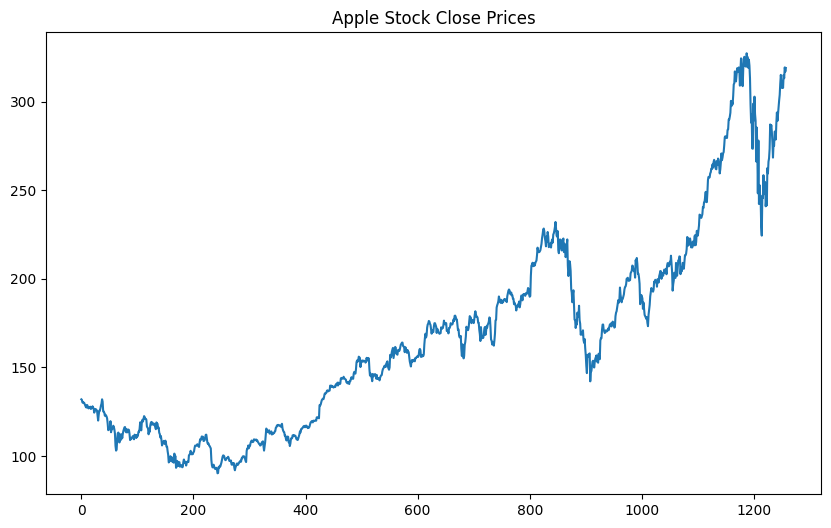

In [29]:
# Close price column select
df1 = df.reset_index()['close']

# Plot original close prices
plt.figure(figsize=(10,6))
plt.plot(df1)
plt.title("Apple Stock Close Prices")
plt.show()

# Scale data
scaler = MinMaxScaler(feature_range=(0,1))
df1 = scaler.fit_transform(np.array(df1).reshape(-1,1))



In [30]:
training_size = int(len(df1)*0.65)
test_size = len(df1) - training_size
train_data, test_data = df1[0:training_size,:], df1[training_size:len(df1),:1]



In [33]:
def create_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-time_step-1):
        a = dataset[i:(i+time_step), 0]
        dataX.append(a)
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)



In [32]:
# Reshape input for LSTM
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


In [34]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(100,1)))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# Train model
model.fit(X_train, y_train, validation_data=(X_test,ytest), epochs=100, batch_size=64, verbose=1)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 210ms/step - loss: 0.0226 - val_loss: 0.0591
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - loss: 0.0044 - val_loss: 0.0048
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 234ms/step - loss: 0.0016 - val_loss: 0.0056
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - loss: 8.5175e-04 - val_loss: 0.0063
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step - loss: 7.5548e-04 - val_loss: 0.0051
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - loss: 6.9896e-04 - val_loss: 0.0040
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - loss: 6.2296e-04 - val_loss: 0.0041
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step - loss: 6.1632e-04 - val_loss: 0.0044
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - loss: 6.2566e-04 - val_loss: 0.0044
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step - loss: 6.5182e-04 - val_loss: 0.0042
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - loss: 6.3570e-04 - val_loss: 0.0042
Epoch 12/100
12/12 ━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


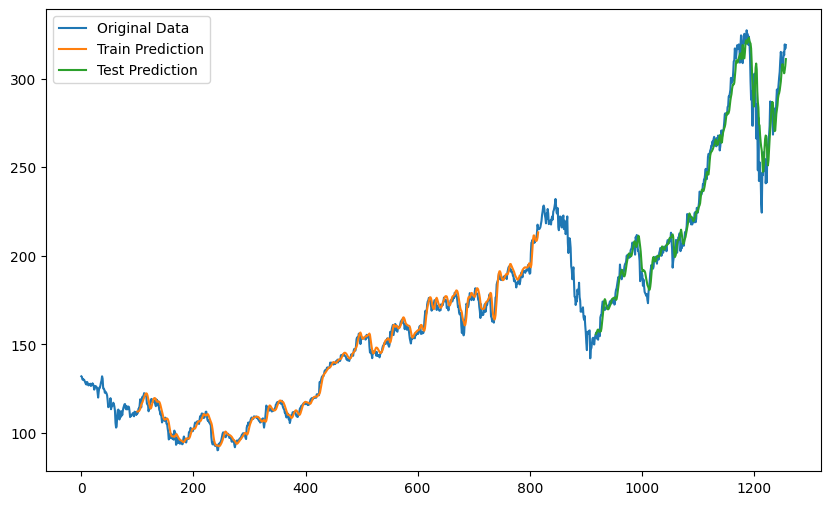

In [35]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform to original scale
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

# Plot results
plt.figure(figsize=(10,6))
plt.plot(scaler.inverse_transform(df1), label='Original Data')
plt.plot(range(time_step, time_step+len(train_predict)), train_predict, label='Train Prediction')
plt.plot(range(len(df1)-len(test_predict), len(df1)), test_predict, label='Test Prediction')
plt.legend()
plt.show()
